<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\marwa_litxmy9\AppData\Local\Temp\ipykernel_24420\2316627025.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('data/ETH/seq_eth/obsmat.txt', sep='\s+', header=None,


Nombre de frames : 1448
Nombre de piétons : 360

Aperçu des données :
   frame  ped_id          x    y        vx        vy   ax        ay
0  780.0     1.0   8.456844  0.0  3.588066  1.671714  0.0  0.176292
1  786.0     1.0   9.125530  0.0  3.658583  1.662877  0.0  0.326723
2  792.0     1.0   9.787146  0.0  3.849445  1.683334  0.0  0.371084
3  798.0     1.0  10.472197  0.0  3.955450  1.598568  0.0  0.264795
4  804.0     1.0  11.066000  0.0  4.061280  1.574526  0.0  0.456390
5  804.0     2.0  13.017548  0.0  5.782591 -2.324444  0.0 -0.076606
6  810.0     1.0  11.731818  0.0  4.320563  1.644127  0.0  0.544391
7  810.0     2.0  12.087770  0.0  5.751949 -1.589052  0.0 -0.065971
8  816.0     1.0  12.381302  0.0  4.496793  1.623709  0.0  0.440576
9  816.0     2.0  11.746306  0.0  5.729815 -1.140766  0.0  0.105373

Vitesse moyenne : 5.55 m/s
Vitesse max : 13.29 m/s


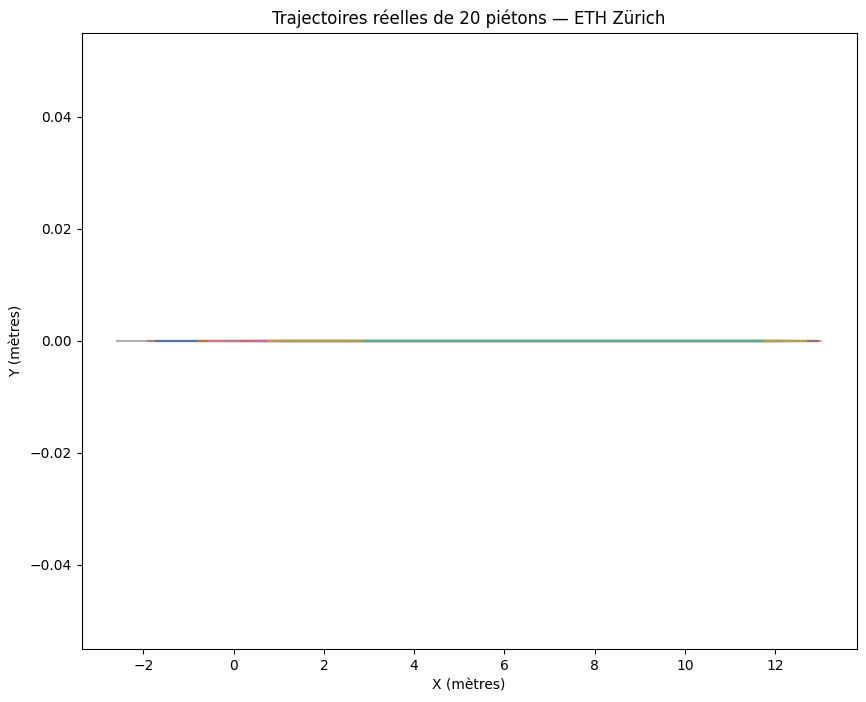

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger les vraies données ETH
df = pd.read_csv('data/ETH/seq_eth/obsmat.txt', sep='\s+', header=None,
                 names=['frame','ped_id','x','y','vx','vy','ax','ay'])

# Aperçu
print(f"Nombre de frames : {df.frame.nunique()}")
print(f"Nombre de piétons : {df.ped_id.nunique()}")
print(f"\nAperçu des données :")
print(df.head(10))

# Calculer la vitesse
df['speed'] = np.sqrt(df.vx**2 + df.vy**2)
print(f"\nVitesse moyenne : {df.speed.mean():.2f} m/s")
print(f"Vitesse max : {df.speed.max():.2f} m/s")

# Visualiser les trajectoires
plt.figure(figsize=(10,8))
for ped in df.ped_id.unique()[:20]:  # 20 premiers piétons
    traj = df[df.ped_id == ped]
    plt.plot(traj.x, traj.y, alpha=0.6)
plt.title('Trajectoires réelles de 20 piétons — ETH Zürich')
plt.xlabel('X (mètres)')
plt.ylabel('Y (mètres)')
plt.show()

In [2]:
import pickle
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Charger les 4 scènes
scenes = [
    'data/ETH/seq_eth/obsmat.txt',
    'data/ETH/seq_hotel/obsmat.txt',
    'data/UCY/zara01/obsmat.txt',
    'data/UCY/zara02/obsmat.txt',
]

frames = []
for path in scenes:
    d = pd.read_csv(path, sep=r'\s+', header=None,
                    names=['frame','ped_id','x','y','vx','vy','ax','ay'])
    d['speed'] = np.sqrt(d.vx**2 + d.vy**2)
    g = d.groupby('frame').agg(
        nb=('ped_id','count'),
        mu=('speed','mean'),
        sd=('speed','std'),
        p90=('speed', lambda x: np.percentile(x,90))
    ).fillna(0)
    frames.append(g)

X = pd.concat(frames)[['nb','mu','sd','p90']].values

# Normaliser
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Entraîner IsolationForest
model = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
model.fit(X_sc)

# Sauvegarder
pickle.dump({'model': model, 'scaler': scaler}, open('model.pkl', 'wb'))

anomalies = (model.predict(X_sc) == -1).sum()
print(f"✅ Modèle entraîné sur {len(X)} frames réelles")
print(f"🚨 Anomalies détectées : {anomalies} ({anomalies/len(X)*100:.1f}%)")

✅ Modèle entraîné sur 4534 frames réelles
🚨 Anomalies détectées : 227 (5.0%)
